In [1]:
gfa_file_path:str = "pggb_yeast_1.gfa"
vcf_file_path:str = "pggb_yeast_1.vcf"
output_vcf = "pggb_branches_1.vcf"
reference_name:str = "CASBJU01"
alternative_names:list[str] = ["CASBIT01","CASBIW01","CASBIZ01","CASBJG01","CASBJH01","CASBJI01","CASBJJ01","CASBJL01","CASBJM01","CASBJN01","CASBJQ01","CASBJS01","CASBJT01","CASBJV01"]


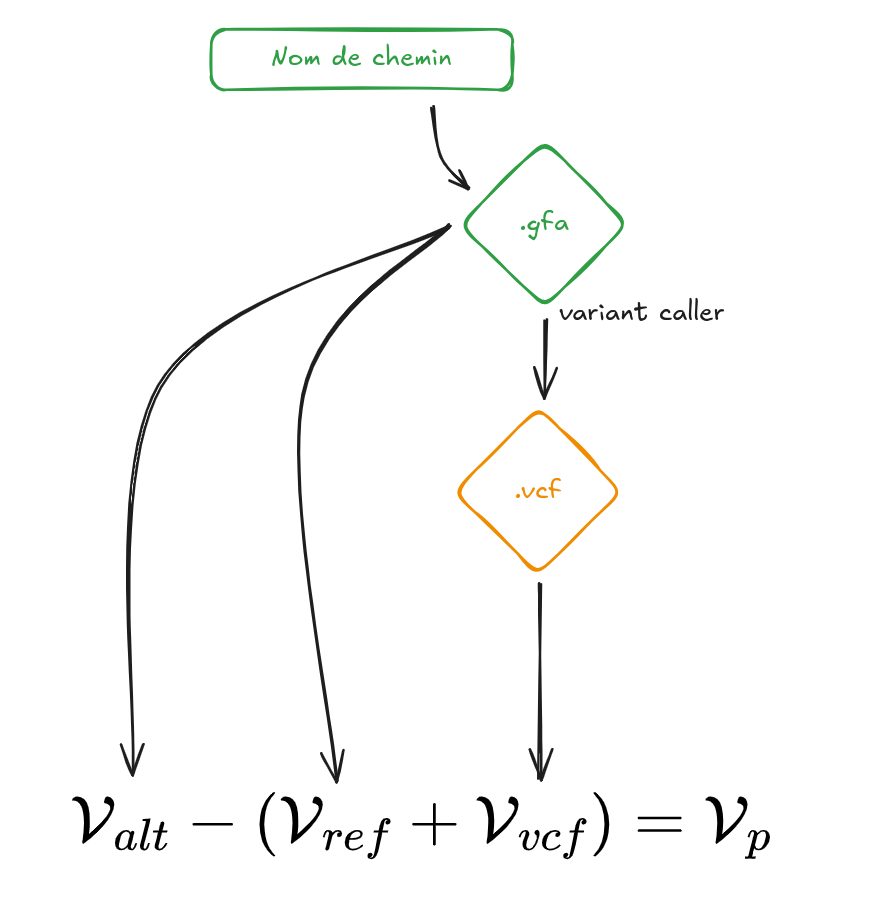


Etape 1 : charger le GFA et obtenir tous les labels des noeuds sous forme d'un set

In [2]:
reference_gfa_set:set = set()
reference_gfa_list:list = list()
reference_gfa_strs:list = list()
alternative_gfa_sets:dict[set] = {path_name:set() for path_name in alternative_names}
alternative_gfa_lists:dict[list] = {path_name:list() for path_name in alternative_names}
alternative_gfa_str:dict[list] = {path_name:list() for path_name in alternative_names}
sequences_dict:dict = dict()

with open(gfa_file_path,'r',encoding='utf-8') as gfa_reader:
    for line in gfa_reader:
        if line.startswith('S'):
            sequences_dict[line.split('\t')[1]] = line.strip().split('\t')[2]
        elif line.startswith('P') and reference_name in line.split('\t')[1]:
            for x in line.split('\t')[2].split(','):
                reference_gfa_set.add(int(x[:-1]))
                reference_gfa_list.append(int(x[:-1]))
                reference_gfa_strs.append(x)

        elif line.startswith('P'):
            for x in line.split('\t')[2].split(','):
                alternative_gfa_sets[line.split('\t')[1]].add(int(x[:-1]))
                alternative_gfa_lists[line.split('\t')[1]].append(int(x[:-1]))
                alternative_gfa_str[line.split('\t')[1]].append(x)
                

print("Number of nodes in graph: " + str(len(sequences_dict)))

for path_name in alternative_names:
    private_alternative_sets:dict[set] = {path_name:alternative_gfa_sets[path_name] - reference_gfa_set for path_name in alternative_names}

print(reference_name + ": " + str(len(reference_gfa_set)) + " nodes ("+ str(sum([len(sequences_dict[str(x)]) for x in reference_gfa_set])) +" bp)")
for alternative_name,alternative_gfa_set in alternative_gfa_sets.items():
    print(alternative_name +": "+ str(len(alternative_gfa_set)) + " nodes ("+ str(sum([len(sequences_dict[str(x)]) for x in alternative_gfa_set])) +" bp) || "+ alternative_name + " - " + reference_name + ": " + str(len(private_alternative_sets[alternative_name])) + " nodes ("+ str(sum([len(sequences_dict[str(x)]) for x in private_alternative_sets[alternative_name]])) +" bp)")

Number of nodes in graph: 27213
CASBJU01: 16575 nodes (214140 bp)
CASBIT01: 14093 nodes (197082 bp) || CASBIT01 - CASBJU01: 1540 nodes (4602 bp)
CASBIW01: 11739 nodes (190963 bp) || CASBIW01 - CASBJU01: 2600 nodes (12768 bp)
CASBIZ01: 8974 nodes (185943 bp) || CASBIZ01 - CASBJU01: 1655 nodes (20867 bp)
CASBJG01: 12534 nodes (192940 bp) || CASBJG01 - CASBJU01: 1402 nodes (3808 bp)
CASBJH01: 11556 nodes (206799 bp) || CASBJH01 - CASBJU01: 2769 nodes (31441 bp)
CASBJI01: 15381 nodes (221246 bp) || CASBJI01 - CASBJU01: 2715 nodes (22699 bp)
CASBJJ01: 16566 nodes (221859 bp) || CASBJJ01 - CASBJU01: 1981 nodes (14987 bp)
CASBJL01: 12750 nodes (192342 bp) || CASBJL01 - CASBJU01: 1839 nodes (3876 bp)
CASBJM01: 14412 nodes (209422 bp) || CASBJM01 - CASBJU01: 2882 nodes (20704 bp)
CASBJN01: 12406 nodes (197759 bp) || CASBJN01 - CASBJU01: 1582 nodes (9626 bp)
CASBJQ01: 15336 nodes (204542 bp) || CASBJQ01 - CASBJU01: 1278 nodes (4726 bp)
CASBJS01: 11216 nodes (205487 bp) || CASBJS01 - CASBJU01: 25

In [3]:
# Affichages divers pour permettre des visualisations dans bandage
# print(','.join([str(x) for x in reference_gfa_set]))
# print(','.join([str(x) for x in alternative_gfa_set]),file=open("alternative_gfa_set.txt",'w'))
# print(','.join([str(x) for x in alternative_gfa_set.intersection(reference_gfa_set)]))
# print(','.join([str(x) for x in alternative_gfa_set.union(reference_gfa_set)]),file=open("gfa_set.txt",'w'))

Etape 2 : obtenir les labels des noeuds dans le VCF qui décrivent de la variation

In [4]:
from collections import Counter

alternative_vcf_sets:dict[set] = {path_name:set() for path_name in alternative_names}
headers:list = list()
alt_pos:dict = {path_name:0 for path_name in alternative_names}
incorrects_formattings:list[str] = list()

with open(vcf_file_path,'r',encoding='utf-8') as vcf_reader:
    for line in vcf_reader:
        if line.startswith('##'):
            continue
        elif line.startswith('#'):
            headers = line.strip().split('\t')
            for path_name in alternative_names:
                alt_pos[path_name] = headers.index(path_name)
        else:
            for path_name in alternative_names:
            # on check si le genome alt est décrit en génotype par un entier 1...n
                try:
                    has_variant:int = int(line.split('\t')[alt_pos[path_name]])
                except:
                    incorrects_formattings.append(line.split('\t')[alt_pos[path_name]])
                    has_variant:int = -1
                # si c'est 0 ou -1, c'est que ce n'est pas correctement décrit comme variant
                if has_variant > 0:
                    # On doit aller chercher la bonne position du variant dans le champ AT (pas besoin de conserver le sens)
                    alternative_vcf_sets[path_name].update([int(x) for x in line.split('\t')[7].split(';')[3].split(',')[has_variant].replace('<','>')[1:].split('>')])

#print(len(alternative_vcf_set))

#print(len(incorrects_formattings))

#print(Counter(incorrects_formattings))


resulting_sets:dict[set] = {path_name:private_alternative_sets[path_name] - alternative_vcf_sets[path_name] for path_name in alternative_names}

for path_name in alternative_names:
    print(path_name + ": " + str(len(resulting_sets[path_name])))



CASBIT01: 229
CASBIW01: 611
CASBIZ01: 131
CASBJG01: 192
CASBJH01: 649
CASBJI01: 98
CASBJJ01: 163
CASBJL01: 627
CASBJM01: 990
CASBJN01: 383
CASBJQ01: 292
CASBJS01: 458
CASBJT01: 137
CASBJV01: 873


In [5]:
# print(','.join([str(x) for x in resulting_set]))
# print(','.join([str(x) for x in alternative_vcf_set]))

On vérifie que les morceaux ne sont pas décrits comme des variants

In [6]:
# with open(vcf_file_path,'r',encoding='utf-8') as vcf_reader:
#     for line in vcf_reader:
#         if line.startswith('##'):
#             continue
#         elif line.startswith('#'):
#             headers = line.split('\t')
#             alt_pos = headers.index(alternative_name)
#         else:
#             # on check si le genome alt est décrit en génotype par un entier 1...n
#             try:
#                 has_variant:int = int(line.split('\t')[alt_pos])
#             except:
#                 incorrects_formattings.append(line.split('\t')[alt_pos])
#                 has_variant:int = -1
#             # si c'est 0 ou -1, c'est que ce n'est pas correctement décrit comme variant
#             if has_variant > 0:
#                 # On doit aller chercher la bonne position du variant dans le champ AT (pas besoin de conserver le sens)
#                 y:list = [int(x) for x in line.split('\t')[7].split(';')[3].split(',')[has_variant].replace('<','>')[1:].split('>')]
#                 if any([x in resulting_set for x in y]):
#                     print(line)

On va rechercher comment ces non-variants s'inscrivent dans le graphe. Ont-ils des liens à la référence ? Sont-ils encadrés, de près ou de loin, à des noeuds appartenant à la référence ?

On va chercher les index des noeuds qui font partie de notre set de non-variants, définir un cutoff, et chercher si les noeuds à droite et gauche jusqu'au cutoff ou avant sont dans l'intersection

In [7]:
intersect:set = alternative_gfa_set.intersection(reference_gfa_set)
node_pairs:dict[set[tuple]] = {path_name:set() for path_name in alternative_names}
chains_lists:dict[list] = {path_name:list() for path_name in alternative_names}

for path_name in alternative_names:
    count_rescuables_nodes:int = 0
    for node_id in resulting_sets[path_name]:
        idx:int = alternative_gfa_lists[path_name].index(node_id)
        bubble_branch:list = [alternative_gfa_str[path_name][idx]]
        # We assume we have a single occurence, we search the first index
        cutoff:int = min(int(len(alternative_gfa_lists[path_name])/10),idx,len(alternative_gfa_lists[path_name])-idx) -1
        x,y = 0,0
        dist = 1
        while not x and cutoff >= dist:
            bubble_branch = [alternative_gfa_str[path_name][idx-dist]] + bubble_branch
            if alternative_gfa_lists[path_name][idx-dist] in intersect:
                x = alternative_gfa_lists[path_name][idx-dist]
            dist+=1
        dist = 1
        while not y and cutoff >= dist:
            bubble_branch = bubble_branch + [alternative_gfa_str[path_name][idx+dist]]
            if alternative_gfa_lists[path_name][idx+dist] in intersect:
                y = alternative_gfa_lists[path_name][idx+dist]
            dist+=1
        if x and y:
            count_rescuables_nodes+=1
            node_pairs[path_name].add((x,y))
            chains_lists[path_name].append(bubble_branch)
    print(f"Graph path {path_name} contains at least {count_rescuables_nodes} rescuable nodes ({round(count_rescuables_nodes/len(resulting_sets[path_name])*100,2)}%).")


Graph path CASBIT01 contains at least 82 rescuable nodes (35.81%).
Graph path CASBIW01 contains at least 600 rescuable nodes (98.2%).
Graph path CASBIZ01 contains at least 129 rescuable nodes (98.47%).
Graph path CASBJG01 contains at least 155 rescuable nodes (80.73%).
Graph path CASBJH01 contains at least 509 rescuable nodes (78.43%).
Graph path CASBJI01 contains at least 0 rescuable nodes (0.0%).
Graph path CASBJJ01 contains at least 109 rescuable nodes (66.87%).
Graph path CASBJL01 contains at least 433 rescuable nodes (69.06%).
Graph path CASBJM01 contains at least 978 rescuable nodes (98.79%).
Graph path CASBJN01 contains at least 113 rescuable nodes (29.5%).
Graph path CASBJQ01 contains at least 262 rescuable nodes (89.73%).
Graph path CASBJS01 contains at least 298 rescuable nodes (65.07%).
Graph path CASBJT01 contains at least 135 rescuable nodes (98.54%).
Graph path CASBJV01 contains at least 828 rescuable nodes (94.85%).


On va chercher à obtenir les chaînes pour les observer. Peut-on trouver les chaînes dans la référence et récupérer les variants ?

In [8]:
# Nombre de bubbles à secourir
sum([len(np) for np in node_pairs.values()])

1867

In [9]:
def revcomp(string: str, compl: dict = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 'N': 'N'}) -> str:
    """Tries to compute the reverse complement of a sequence

    Args:
        string (str): original character set
        compl (dict, optional): dict of correspondances. Defaults to {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}.

    Raises:
        IndexError: Happens if revcomp encounters a char that is not in the dict

    Returns:
        str: the reverse-complemented string
    """
    try:
        return ''.join([compl[s] for s in string][::-1])
    except IndexError as exc:
        raise IndexError(
            "Complementarity does not include all chars in sequence.") from exc

In [10]:
bubbles_dict = dict()
bubbles_positions = dict()
bubbles_positions_alt = dict()

for path_name in alternative_names:
    for a,b in node_pairs[path_name]:
        idx_a,idx_b = reference_gfa_list.index(a),reference_gfa_list.index(b)
        bubbles_dict[(a,b)] = reference_gfa_strs[min(idx_a,idx_b):max(idx_a+1,idx_b+1)]
        bubbles_positions[(a,b)] = sum([len(sequences_dict[x[:-1]]) for x in reference_gfa_strs[0:min(idx_a,idx_b)]])
        bubbles_positions_alt[(a,b)] = sum([len(sequences_dict[x[:-1]]) for x in alternative_gfa_str[path_name][0:min(idx_a,idx_b)]])

# Observer si les bubbles sont imbriquées

+ Parser le VCF
+ extraire les chaînes liées à la référence
+ intersection entre les E/S de la bubble détectée et des chaînes de référence dans le VCF
+ taille de l'intersection = statut (0 => non imbriquée, 1 => chevauchant, 2 => imbriqué avec ou sans cycle)
+ 

In [11]:
reference_chains:list[list[int]] = list()

with open(vcf_file_path,'r',encoding='utf-8') as vcf_reader:
    for line in vcf_reader:
        if line.startswith('##') or line.startswith('#'):
            continue
        else:
            # on récupère la chaîne de référence
            reference_chains.append([int(x) for x in line.split('\t')[7].split(';')[3].split(',')[0].replace('<','>')[4:].split('>')])

In [12]:
from os.path import exists
from os import remove


if exists(output_vcf):
    remove(output_vcf)

pairlist = list()

for path_name in alternative_names:
    for bubble in chains_lists[path_name]:
        bubble_name = ('>' if bubble[0][-1] == '+' else '<')+bubble[0][:-1]+('>' if bubble[-1][-1] == '+' else '<')+bubble[-1][:-1]
        bubble_anchors:set[int] = {int(bubble[0][:-1]),int(bubble[1][:-1])}
        intricate = [len(bubble_anchors.intersection(x[1:-1])) for x in reference_chains]
        if sum(intricate) == 0:
            status = '0'
        else:
            intricate = sorted([x for x in intricate if x != 0])
            if intricate[0] == 1 and intricate[-1] == 2:
                status = '1|2'
            else:
                status = str(intricate[0])

        if bubble_name in pairlist:
            continue
        else:
            pairlist.append(bubble_name)
            print(
                reference_name+
                '\t'+
                str(bubbles_positions[(int(bubble[0][:-1]),int(bubble[-1][:-1]))])+
                '\t'+
                str(bubbles_positions_alt[(int(bubble[0][:-1]),int(bubble[-1][:-1]))])+
                '\t'+
                bubble_name+
                '\t'+
                ''.join([sequences_dict[idd[:-1]] if idd[-1] == '+' else revcomp(sequences_dict[idd[:-1]]) for idd in bubbles_dict[(int(bubble[0][:-1]),int(bubble[-1][:-1]))]][1:-1])+
                '\t'+
                ''.join([sequences_dict[idd[:-1]] if idd[-1] == '+' else revcomp(sequences_dict[idd[:-1]]) for idd in bubble][1:-1])+
                '\t'+'60'+
                '\t'+'.'+
                "\t"+
                "AC="+";"+
                "AF="+";"+
                "AN="+";"+
                "AT="+
                ''.join([(">" if idd[-1] == '+' else '<')+str(idd)[:-1] for idd in bubbles_dict[(int(bubble[0][:-1]),int(bubble[-1][:-1]))]])+','+''.join([(">" if idd[-1] == '+' else '<')+str(idd)[:-1] for idd in bubble])+";"+
                "NS="+";"+
                "LV="+";"+
                "IT="+status
                ,file=open(output_vcf,'a+')
            )

In [13]:
# maintenant qu'on a sorti un vcf, pour savoir le nombre de bulles qu'on a découvertes, il suffit de parser et de récupérer l'ID de la bulle
# on compare cette liste d'ID uniques -> on regarde par rapport au vcf d'origine

id_set_new:set = set()
id_set_old:set = set()

with open(output_vcf,'r') as reader:
    for line in reader:
        id_set_new.add(line.split('\t')[3])

with open(vcf_file_path,'r') as reader:
    for line in reader:
        if not line.startswith('#'):
            id_set_old.add(line.split('\t')[2])

print(f"Added {len(id_set_new)-len(id_set_new.intersection(id_set_old))} new bubbles and updated {len(id_set_new.intersection(id_set_old))} bubbles out of {len(id_set_old)} old bubbles")

Added 1046 new bubbles and updated 434 bubbles out of 7874 old bubbles
